## XGBoost Model



- Define features and label (number of conflicts, for each ZIP in PA, for each month)
- Perform 5-fold time-series-cross-validation
- Split the data 70/30 train and test
- Normalize the sets
- Define the xgb regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from joblib import Parallel, delayed, dump, load

In [17]:
#Dynamic search path configuration
import sys
import os

#Adjusting search path based on notebook's depth in directory --> iterates through directories until it finds directory name: US_conflict_forecasting
current_dir = os.getcwd()
while 'US_conflict_forecasting' not in os.path.basename(current_dir):
    current_dir = os.path.dirname(current_dir)

#Adjusting search path based on 'new' current directory
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

from project_setup import setup_project
project_root_dir = setup_project()

import pandas as pd

### Load the data

In [18]:
# Load the data

data = pd.read_csv(os.path.join(project_root_dir, '2_Dataset/d_Final_Dataset/Final_Dataset_noLag_clean.csv'))

### Features and labels, cross-validation, split and normalization

In [19]:
train = data[data['month'] <= 9]

test = data[data['month'] > 9]

In [20]:
X_train = train.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_train = train['event_count']


X_test = test.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_test = test['event_count']

In [21]:
# Time Series Cross Validation, 5 folds.

tscv = TimeSeriesSplit(n_splits=5)

In [22]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Initialize and fit the XGBoost Regressor

In [23]:
xgb = XGBRegressor(use_label_encoder = False, eval_metric = 'logloss', random_state = 1 )
xgb.fit(X_train_scaled, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='logloss',
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, random_state=1, ...)

### Run Grid Search to find the best parameters:

In [24]:
param_grid = {
    'max_depth': [3, 4],
    'min_child_weight': [1, 2],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [50, 70],
    'subsample': [0.6, 0.7],
    'colsample_bytree': [0.6, 0.7]
}

# About 320 fits on a 5 fold cv

In [25]:
param_grid_1 = {
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 2, 3],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

# 3240 fits on a 5 fold cv

In [26]:
import joblib

def progress_printout(n_completed, n_tasks, *args, **kwargs):
    if n_completed % 10 == 0:
        print(f"{n_completed}/{n_tasks} fits completed")

In [27]:
# Set up a custom progress printout for joblib
with joblib.parallel.parallel_backend('threading', n_jobs=-1):
    joblib.parallel.parallel_printout = progress_printout

# Initialize XGB and GridSearch
grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid, scoring='neg_mean_squared_error', cv=tscv, verbose = 2, n_jobs = -1)
grid_search.fit(X_train_scaled, Y_train)

# Print the best parameters
best_params = grid_search.best_params_
print("Best parameters:", best_params)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 70, 'subsample': 0.7}


### Re-run the model with optimal parameter values

In [28]:
# Re-train the model with the best parameters found above
xgb_optimized = XGBRegressor(**best_params, use_label_encoder=False, eval_metric='logloss', random_state = 1)
xgb_optimized.fit(X_train_scaled, Y_train)

# Make predictions
y_pred_optimized = xgb_optimized.predict(X_test_scaled)

### Run feature importance analysis

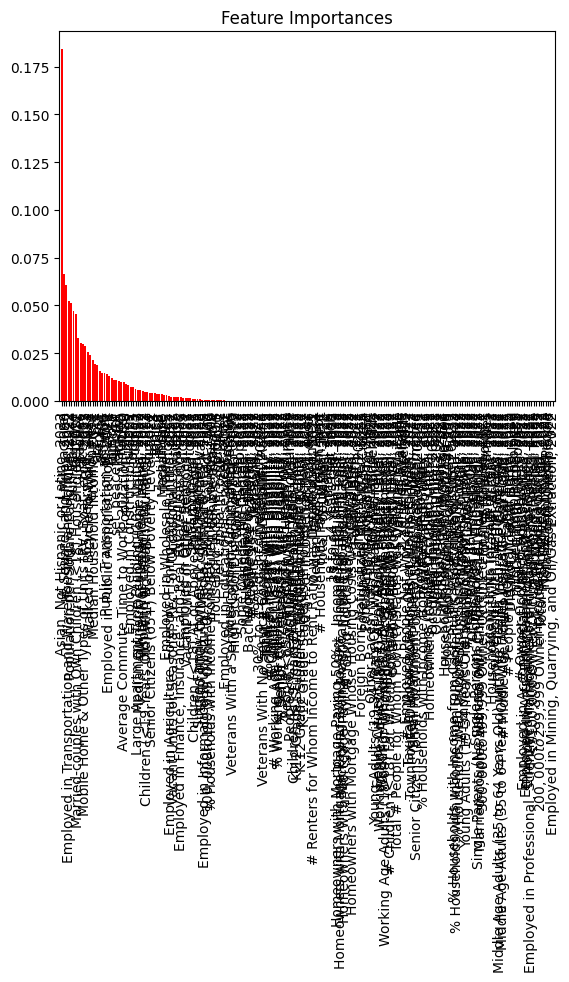

In [29]:
importances = xgb_optimized.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure()
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importances[indices], color='r', align='center')
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [30]:
print(importances)

[3.06207128e-02 2.97403391e-02 1.90743729e-02 1.48408124e-02
 6.64300397e-02 1.44501124e-02 4.53943238e-02 1.05909705e-02
 6.04559435e-04 1.18907439e-02 1.11458302e-02 3.67210159e-04
 1.71097985e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
 8.34846962e-03 2.17229892e-02 4.73482497e-02 3.53427674e-03
 0.00000000e+00 8.87215976e-03 6.05895780e-02 5.12781702e-02
 7.97871980e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00
 8.95566016e-04 0.00000000e+00 0.00000000e+00 2.58399379e-02
 3.07277264e-03 5.28409332e-03 0.00000000e+00 1.84238553e-01
 0.00000000e+00 0.00000000e+00 4.81097028e-03 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.34725099e-06
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.000000

### Find best number of features and cross-validation folds

In [31]:
# Empty list to store and run different cv scores
cv_scores = []

for i in range(1, len(indices) + 1):
    # Select the top 'i' features
    top_features = [X_train.columns[indices[j]] for j in range(i)]
    
    # Create the training data using the selected features
    X_train_top = X_train_scaled[:, indices[:i]]
    
    # Initialize the model with the best parameters
    model = XGBRegressor(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=42)
    
    # Perform cv at 5 and store the mean score
    scores = cross_val_score(model, X_train_top, Y_train, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(scores.mean())

# Which number of features gives the highest cv score?
optimal_features = np.argmax(cv_scores) + 1 
optimal_score = cv_scores[optimal_features - 1]

print(f"Optimal number of features: {optimal_features}")
print(f"Highest CV accuracy: {optimal_score:.2f}%")

Optimal number of features: 143
Highest CV accuracy: -0.12%


### Plot

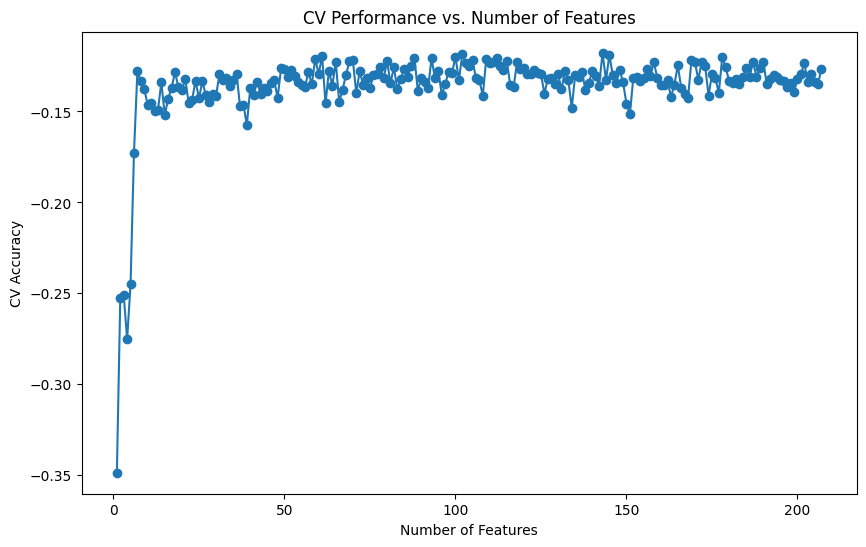

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(indices) + 1), cv_scores, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('CV Accuracy')
plt.title('CV Performance vs. Number of Features')
plt.show()

### Re-run with best features

In [33]:
# Select opimal features
top_features_indices = indices[:optimal_features]
X_train_optimal = X_train_scaled[:, top_features_indices]
X_test_optimal = X_test_scaled[:, top_features_indices]

# Train the model using the selected subset of features
model_optimal = XGBRegressor(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=42)
model_optimal.fit(X_train_optimal, Y_train)

# Evaluate the model on the test set
y_pred_optimal = model_optimal.predict(X_test_optimal)
mse_optimal = mean_squared_error(Y_test, y_pred_optimal)
accuracy_optimal = 100 - mse_optimal

print(f"Test set accuracy with optimal number of features ({optimal_features}): {accuracy_optimal:.2f}%")

Test set accuracy with optimal number of features (143): 99.86%


In [34]:
predictions = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_optimal})

In [36]:
ZIP_results = pd.merge(predictions, data[['ZCTA', 'month']], left_index=True, right_index=True)

In [37]:
ZIP_results = ZIP_results[ZIP_results['Predicted'] > 0]

In [38]:
mse = mean_squared_error(Y_test, y_pred_optimal)

print('Mean Squared Error:', mse)

Mean Squared Error: 0.14391903029734696


In [39]:
output_directory_1 = os.path.join(project_root_dir, '3_Models')
output_filename_1 = "xgb_no_lag.csv"
output_path_1 = os.path.join(output_directory_1, output_filename_1)

dump(model_optimal, output_path_1)

['/Users/danie/Desktop/Hertie/2. Semester/1. ML/0. Final Project/US_conflict_forecasting\\3_Models\\xgb_no_lag.csv']